In [1]:
import pandas as pd
from scipy.stats import f_oneway

# Load CSV
file_path = "/Users/guangyaoquan/Downloads/results.csv"
df = pd.read_csv(file_path)

### Correlate transform types with everything

In [2]:
# Step 1: Correlation

# Encode transform_type as category codes for correlation
custom_order = ['TransformType.NONE', 'TransformType.LINEAR', 'TransformType.NONLINEAR']
df['transform_type_encoded'] = pd.Categorical(
    df['transform_type'],
    categories=custom_order,
    ordered=True
).codes

# Get the category mapping
transform_mapping = dict(zip(range(len(custom_order)), custom_order))
print("Transform type mapping (code -> label):", transform_mapping)

# Exclude specific columns from correlation analysis
exclude_cols = ['transform_type_encoded', 'experienced', 'group']
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude_cols)

# Ensure numeric columns have non-zero standard deviation
numeric_cols = [col for col in numeric_cols if df[col].std() > 0]

# Calculate correlations
correlations = df[numeric_cols].corrwith(df['transform_type_encoded']).sort_values(ascending=False)

print("\n=== Correlation with Transform Type ===")
print(correlations)

Transform type mapping (code -> label): {0: 'TransformType.NONE', 1: 'TransformType.LINEAR', 2: 'TransformType.NONLINEAR'}

=== Correlation with Transform Type ===
synchronised_count                    0.308925
double_click_Yellow2_count            0.043541
double_click_Green2_count             0.018453
double_click_Yellow1_count           -0.021224
double_click_Red2_count              -0.033155
wheel_scroll_distance_c              -0.061030
zoom_usage_count                     -0.068944
zoom_total_distance_px               -0.070202
double_click_Green1_count            -0.080675
bifurcation_rel_a_vertebralis_l      -0.081991
window_level_total_distance_px       -0.096335
window_level_usage_count             -0.098278
double_click_Red1_count              -0.099691
duration_seconds                     -0.104195
pan_usage_count                      -0.117732
pan_total_distance_px                -0.140757
slider_total_distance_mm             -0.141176
slider_usage_count                   

In [3]:
# compute each transformation type's mean for each numeric column
mean_by_transform = df.groupby('transform_type')[numeric_cols].mean().T

# rearrange columns to match custom order
mean_by_transform = mean_by_transform[custom_order]
print("\n=== Rearranged Mean of Numeric Columns by Transform Type ===")
print(mean_by_transform)


=== Rearranged Mean of Numeric Columns by Transform Type ===
transform_type                      TransformType.NONE  TransformType.LINEAR  \
bifurcation_rel_a_carotisexterna_l            5.880222              3.221852   
bifurcation_rel_a_carotisexterna_r            4.529565              2.817851   
bifurcation_rel_a_vertebralis_l               5.678818              6.398729   
bifurcation_rel_a_vertebralis_r               7.906121              5.902671   
double_click_Green1_count                     0.333333              0.185897   
double_click_Green2_count                     0.121795              0.102564   
double_click_Red1_count                       0.602564              0.500000   
double_click_Red2_count                       0.134615              0.160256   
double_click_Yellow1_count                    0.070513              0.083333   
double_click_Yellow2_count                    0.032051              0.032051   
drag_scroll_total_distance_px              1578.934085    

In [4]:
# Step 2: ANOVA

# Drop rows where transform_type is missing
df_clean = df.dropna(subset=['transform_type'])

# Unique transform types
transform_types = df_clean['transform_type'].unique()

# Perform ANOVA
anova_results = {}
for col in numeric_cols:
    groups = [df_clean[df_clean['transform_type'] == t][col].dropna() for t in transform_types]
    if all(len(g) > 1 for g in groups):  # Only test if all groups have more than 1 value
        stat, pval = f_oneway(*groups)
        anova_results[col] = pval

# Convert to DataFrame and sort by significance
anova_df = pd.DataFrame(anova_results.items(), columns=["feature", "p_value"]).sort_values("p_value")

print("\n=== ANOVA Results by Transform Type ===")
print(anova_df.reset_index(drop=True))


=== ANOVA Results by Transform Type ===
                               feature       p_value
0              drag_scroll_usage_count  2.945480e-16
1                   synchronised_count  9.573916e-14
2        drag_scroll_total_distance_px  4.145468e-10
3                   slider_usage_count  1.402356e-04
4                pan_total_distance_px  8.287667e-04
5             slider_total_distance_mm  9.844079e-04
6      bifurcation_rel_a_vertebralis_r  2.817675e-03
7                      pan_usage_count  5.282270e-03
8                     duration_seconds  6.055028e-02
9       window_level_total_distance_px  6.929691e-02
10           double_click_Green1_count  7.973191e-02
11            window_level_usage_count  8.105139e-02
12             double_click_Red1_count  9.234893e-02
13  bifurcation_rel_a_carotisexterna_l  1.156077e-01
14              zoom_total_distance_px  1.180169e-01
15                    zoom_usage_count  1.311216e-01
16  bifurcation_rel_a_carotisexterna_r  2.763522e-01
17   

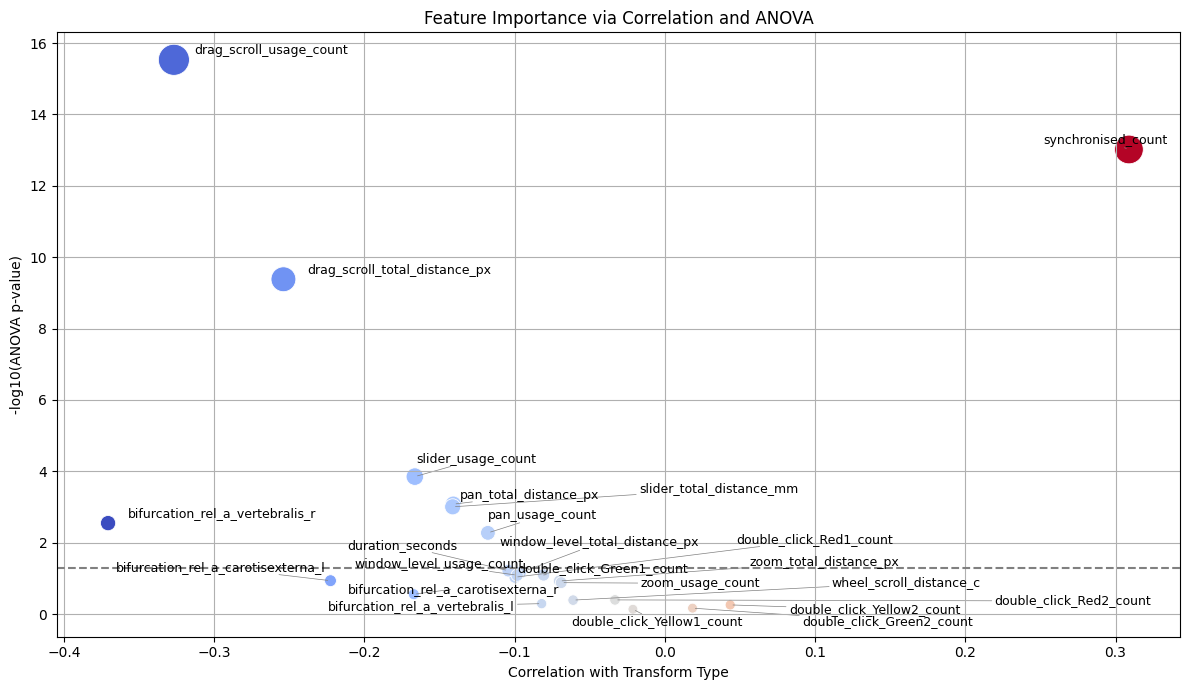

In [5]:
# Bubble plot: correlation vs -log10(p-value)

# Interpretation:
# - Higher correlation indicates a stronger linear relationship/trend between the feature and the transform type.
# - Lower p-value (i.e., higher -log10(p)) indicates more statistically significant

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Merge correlation and anova dataframes
combined_df = pd.DataFrame({
    'correlation': correlations,
    'p_value': anova_df.set_index('feature')['p_value']
}).dropna()

# Compute -log10(p-value)
combined_df['neg_log_pval'] = -np.log10(combined_df['p_value'])

# Plot
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=combined_df,
    x='correlation',
    y='neg_log_pval',
    size='neg_log_pval',
    hue='correlation',
    palette='coolwarm',
    sizes=(50, 500),
    legend=False
)

# Dashed line at p = 0.05 (standard significance level)
plt.axhline(-np.log10(0.05), ls='--', color='gray', label='p = 0.05')

# Add text labels and avoid overlap
texts = []
for feature, row in combined_df.iterrows():
    texts.append(plt.text(row['correlation'], row['neg_log_pval'], feature, fontsize=9))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Final plot settings
plt.xlabel("Correlation with Transform Type")
plt.ylabel("-log10(ANOVA p-value)")
plt.title("Feature Importance via Correlation and ANOVA")
plt.grid(True)
plt.tight_layout()
plt.show()

### Correlate TREs (for tasks ['a_vertebralis_r', 'a_vertebralis_l', 'a_carotisexterna_r', 'a_carotisexterna_l']) with everything

In [6]:
import pandas as pd

# Load CSV
results_file_path = "/Users/guangyaoquan/Downloads/results.csv"
results_df = pd.read_csv(results_file_path)

tres_file_path = "/Users/guangyaoquan/Downloads/tres_linear_deformable.csv"
tres_df = pd.read_csv(tres_file_path)

In [7]:
# Define relevant tasks
relevant_tasks = [
    'a_vertebralis_r',
    'a_vertebralis_l',
    'a_carotisexterna_r',
    'a_carotisexterna_l'
]

# Filter results to only those relevant tasks
filtered_results = results_df[results_df['task_id'].isin(relevant_tasks)].copy()

In [8]:
# Merge the two dataframes on patient_id and task_id
merged_df = filtered_results.merge(tres_df, on=['patient_id', 'task_id'], how='inner')

In [9]:
# Select only numerical columns
numeric_cols = merged_df.select_dtypes(include='number').columns.tolist()
if 'group' in numeric_cols:
    numeric_cols.remove('group')

# Ensure numeric columns have non-zero standard deviation
numeric_cols = [col for col in numeric_cols if merged_df[col].std() > 0]

In [10]:
# Split into linear and non-linear transform subsets
linear_df = merged_df[merged_df['transform_type'] == 'TransformType.LINEAR']
nonlinear_df = merged_df[merged_df['transform_type'] == 'TransformType.NONLINEAR']

In [11]:
# Correlation with all numeric metrics (linear)
corr_lin = linear_df[numeric_cols].drop(columns=['tre_def']).corr()['tre_lin'].sort_values(ascending=False)
corr_def = nonlinear_df[numeric_cols].drop(columns=['tre_lin']).corr()['tre_def'].sort_values(ascending=False)

In [12]:
# Display results
print("=== Correlation with tre_lin (Linear Transformations) ===")
print(corr_lin)

print("\n=== Correlation with tre_def (Non-Linear Transformations) ===")
print(corr_def)

=== Correlation with tre_lin (Linear Transformations) ===
tre_lin                               1.000000
bifurcation_rel_a_carotisexterna_l    0.505068
bifurcation_rel_a_carotisexterna_r    0.408201
slider_total_distance_mm              0.366199
slider_usage_count                    0.310634
duration_seconds                      0.294168
wheel_scroll_distance_c               0.274575
bifurcation_rel_a_vertebralis_l       0.211267
double_click_Red2_count               0.141742
double_click_Green1_count             0.095523
drag_scroll_usage_count               0.047462
drag_scroll_total_distance_px         0.039619
double_click_Red1_count               0.006951
synchronised_count                    0.003286
double_click_Yellow1_count            0.000997
bifurcation_rel_a_vertebralis_r      -0.005369
double_click_Green2_count            -0.023640
zoom_total_distance_px               -0.059754
double_click_Yellow2_count           -0.067205
zoom_usage_count                     -0.068854
pa

### Compare/correlate TRE (bifurcation_tre and lymph_node_tre) with duration, bifurcation errors (a_vertebralis_r_rel...) etc. between rad_1 and rad_3

In [13]:
# Load the merged results file
results_new = pd.read_csv("/Users/guangyaoquan/Downloads/results_new.csv")

# === Filter for rad_1 and rad_3 only ===
rad_1_df = results_new[results_new["user_id"] == "rad_1"]
rad_3_df = results_new[results_new["user_id"] == "rad_3"]

# === Identify numerical columns, excluding 'group' and the targets ===
numeric_cols = results_new.select_dtypes(include='number').columns.tolist()
target_cols = ["bifurcation_tre", "lymph_node_tre"]
features_to_compare = [col for col in numeric_cols if col not in target_cols + ["group"]]

# === Compute correlations for rad_1 ===
corr_rad_1 = rad_1_df[features_to_compare + target_cols].corr()
corr_rad_1_bif = corr_rad_1["bifurcation_tre"].sort_values(ascending=False)
corr_rad_1_lymph = corr_rad_1["lymph_node_tre"].sort_values(ascending=False)

# === Compute correlations for rad_3 ===
corr_rad_3 = rad_3_df[features_to_compare + target_cols].corr()
corr_rad_3_bif = corr_rad_3["bifurcation_tre"].sort_values(ascending=False)
corr_rad_3_lymph = corr_rad_3["lymph_node_tre"].sort_values(ascending=False)

# === Display results ===
print("=== rad_1: Correlation with bifurcation_tre ===")
print(corr_rad_1_bif)

print("\n=== rad_3: Correlation with bifurcation_tre ===")
print(corr_rad_3_bif)

print("\n=== rad_1: Correlation with lymph_node_tre ===")
print(corr_rad_1_lymph)

print("\n=== rad_3: Correlation with lymph_node_tre ===")
print(corr_rad_3_lymph)

=== rad_1: Correlation with bifurcation_tre ===
bifurcation_tre                   1.000000
drag_scroll_usage_count           0.621233
drag_scroll_total_distance_px     0.511242
pan_total_distance_px             0.446004
pan_usage_count                   0.418728
a_vertebralis_r_rel               0.400142
zoom_usage_count                  0.357558
a_carotisexterna_l_rel            0.349529
zoom_total_distance_px            0.322597
duration_seconds                  0.322399
window_level_usage_count          0.272119
a_carotisexterna_r_rel            0.269213
window_level_total_distance_px    0.235401
double_click_Red2_count           0.222823
double_click_Green1_count         0.151234
a_vertebralis_l_rel               0.148159
slider_total_distance_mm          0.114268
slider_usage_count                0.114268
double_click_Red1_count           0.045693
wheel_scroll_distance_c           0.012422
double_click_Green2_count        -0.015955
double_click_Yellow2_count       -0.075212
double

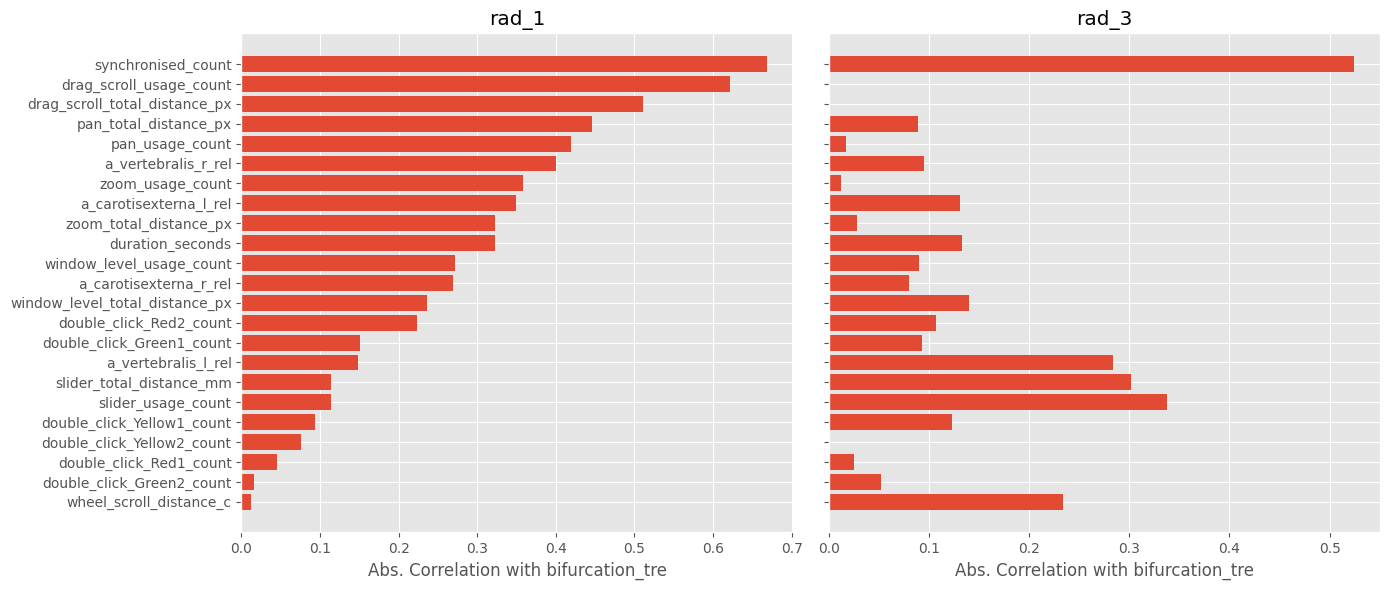

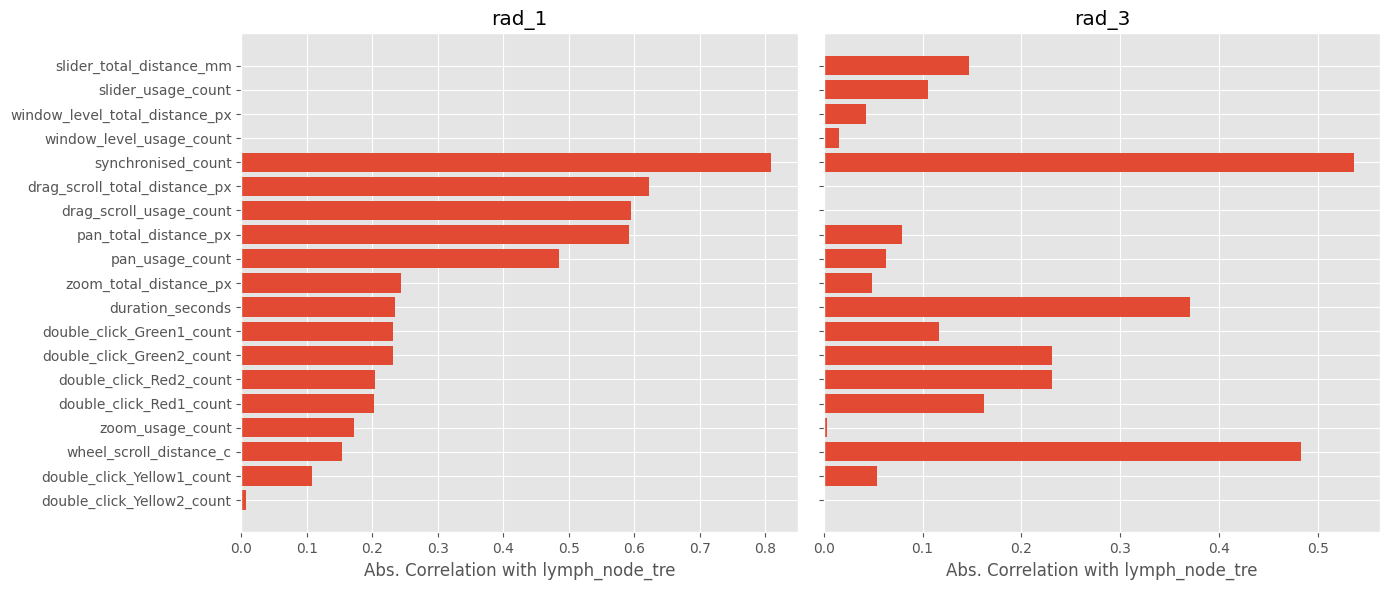

In [14]:
import matplotlib.pyplot as plt

# === Visualization function ===
plt.style.use("ggplot")

def plot_correlation_comparison(corr1, corr2, title1, title2, target_metric):
    # Take top 10 absolute correlations (excluding the target itself)
    # corr1_top = corr1.drop(labels=[target_metric]).dropna().abs().sort_values(ascending=False).head(10)
    # corr2_top = corr2.drop(labels=[target_metric]).dropna().abs().sort_values(ascending=False).head(10)
    corr1_top = corr1.drop(labels=[target_metric]).dropna().abs().sort_values(ascending=False)
    corr2_top = corr2.drop(labels=[target_metric]).dropna().abs().sort_values(ascending=False)

    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

    # Plot for rad_1
    axes[0].barh(corr1_top.index[::-1], corr1_top.values[::-1])
    axes[0].set_title(title1)
    axes[0].set_xlabel(f"Abs. Correlation with {target_metric}")

    # Plot for rad_3
    axes[1].barh(corr2_top.index[::-1], corr2_top.values[::-1])
    axes[1].set_title(title2)
    axes[1].set_xlabel(f"Abs. Correlation with {target_metric}")

    plt.tight_layout()
    plt.show()

# === Plot correlations ===
plot_correlation_comparison(
    corr_rad_1_bif,
    corr_rad_3_bif,
    "rad_1",
    "rad_3",
    "bifurcation_tre"
)

plot_correlation_comparison(
    corr_rad_1_lymph,
    corr_rad_3_lymph,
    "rad_1",
    "rad_3",
    "lymph_node_tre"
)